In [54]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [55]:
import wbgapi as wb
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, precision_recall_curve, f1_score, precision_score, recall_score

In [56]:
indicators = ['NY.GDP.PCAP.KD.ZG', 'NY.GDP.MKTP.KD.ZG', 'FP.CPI.TOTL.ZG', 'SL.UEM.TOTL.ZS', 'GC.DOD.TOTL.GD.ZS', 'BN.CAB.XOKA.GD.ZS', 'BX.KLT.DINV.WD.GD.ZS', 'NE.TRD.GNFS.ZS', 'NY.GNS.ICTR.ZS', 'FM.LBL.BMNY.ZG', 'FR.INR.LEND', 'FR.INR.RINR', 'DT.DOD.DECT.GN.ZS', 'FI.RES.TOTL.MO', 'FS.AST.PRVT.GD.ZS', 'NE.EXP.GNFS.ZS', 'NE.IMP.GNFS.ZS', 'SP.DYN.LE00.IN', 'SP.POP.GROW', 'SL.TLF.CACT.ZS', 'NE.GDI.TOTL.ZS', 'NE.CON.GOVT.ZS', 'MS.MIL.XPND.GD.ZS', 'TX.VAL.TECH.MF.ZS', 'NV.IND.MANF.ZS', 'NV.AGR.TOTL.ZS']

df = wb.data.DataFrame(indicators, time=range(2013, 2020)).mean(axis=1).unstack()
df = df.dropna(thresh=int(0.6*df.shape[1])).dropna(axis=1, thresh=int(0.6*df.shape[0])).fillna(df.median())

df['crisis'] = (df['NY.GDP.PCAP.KD.ZG'] < 0).astype(int)
X, y = df.drop(columns=['NY.GDP.PCAP.KD.ZG', 'crisis']), df['crisis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), index=X_train.index, columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X.columns)

print(f"Dimensions: {X.shape}")
print(f"Crisis countries: {y.sum()}")
print(f"Noncrisis countries: {len(y) - y.sum()}")
print(f"Base rate: {y.mean():.2%}")

Dimensions: (235, 21)
Crisis countries: 38
Noncrisis countries: 197
Base rate: 16.17%


In [57]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns=['NY.GDP.PCAP.KD.ZG', 'crisis']), df['NY.GDP.PCAP.KD.ZG'], test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ols = LinearRegression().fit(X_train_scaled, y_train)

train_r2 = ols.score(X_train_scaled, y_train)
test_r2 = ols.score(X_test_scaled, y_test)
r2_difference = train_r2 - test_r2
pn_ratio = X_train_scaled.shape[1] / X_train_scaled.shape[0]

print(f"Train R2: {train_r2}")
print(f"Test R2: {test_r2}")
print(f"Gap: {r2_difference}")
print(f"pn ratio: {pn_ratio}")

# When there are to many predictors compared to the amount of data, the model
# uses up all of its degrees of freedom to memorize the training set. This causes
# the model to have a low bias, causing the training r2 to inflate. It also suffers
# from high variance when being tested on new data, causing a drop off in the gap.

Train R2: 0.9987284780639999
Test R2: 0.9972010252337591
Gap: 0.0015274528302408052
pn ratio: 0.12804878048780488


In [58]:
from sklearn.metrics import mean_squared_error


ridge = RidgeCV(cv=5).fit(X_train_scaled, y_train)
ridge_alpha = ridge.alpha_
ridge_nonzero = sum(ridge.coef_ != 0)
ridge_train_r2 = ridge.score(X_train_scaled, y_train)
ridge_test_r2 = ridge.score(X_test_scaled, y_test)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge.predict(X_test_scaled)))

lasso = LassoCV(cv=5).fit(X_train_scaled, y_train)
lasso_alpha = lasso.alpha_
lasso_nonzero = sum(lasso.coef_ != 0)
lasso_train_r2 = lasso.score(X_train_scaled, y_train)
lasso_test_r2 = lasso.score(X_test_scaled, y_test)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso.predict(X_test_scaled)))

ols_rmse = np.sqrt(mean_squared_error(y_test, ols.predict(X_test_scaled)))
ols_nonzero = sum(ols.coef_ != 0)

In [59]:
lasso = LassoCV(cv=5).fit(X_train_scaled, y_train)

X_train_lasso = X_train_scaled[:, lasso.coef_ != 0]
X_test_lasso = X_test_scaled[:, lasso.coef_ != 0]

y_train_crisis = df.loc[X_train.index, 'crisis']
lpm = LinearRegression().fit(X_train_lasso, y_train_crisis)
predictions = lpm.predict(X_test_lasso)

oob = sum((predictions < 0) | (predictions > 1))
print(oob)

# Probabilities need to exist between 1 and 0 because anything outside this range would
# be invalid. -12 would be a irrelevant number that wouldn't give proper information.

25


In [64]:
logreg = LogisticRegression().fit(X_train_lasso, y_train_crisis)

print(logreg.intercept_[0])
print(logreg.coef_[0])

odd = np.exp(logreg.coef_[0])
features = X_train.columns[lasso.coef_ != 0]

results_df = pd.DataFrame({
    'Feature': features,
    'Coef': logreg.coef_[0],
    'Odds Ratio': odd
})

probs = logreg.predict_proba(X_test_lasso)[:, 1]
print(probs.min())
print(probs.max())

a = results_df.iloc[0]['Feature']
b = results_df.iloc[0]['Odds Ratio']

print(f"A one standard-deviation increase in {a} multiplies the odds of crisis by {b}, holding all else constant.")

-3.634926566417216
[-0.48383626 -0.20978014  0.2107944  -0.36281714  0.28351482 -0.03717742
  0.05861265 -0.07935555 -0.41300231 -0.1085493  -0.23675422 -3.42239655
  0.54501602  0.11558952  0.22251924  2.01475296]
8.80476637045317e-06
0.9999999956198853
A one standard-deviation increase in BN.CAB.XOKA.GD.ZS multiplies the odds of crisis by 0.6164141244115962, holding all else constant.


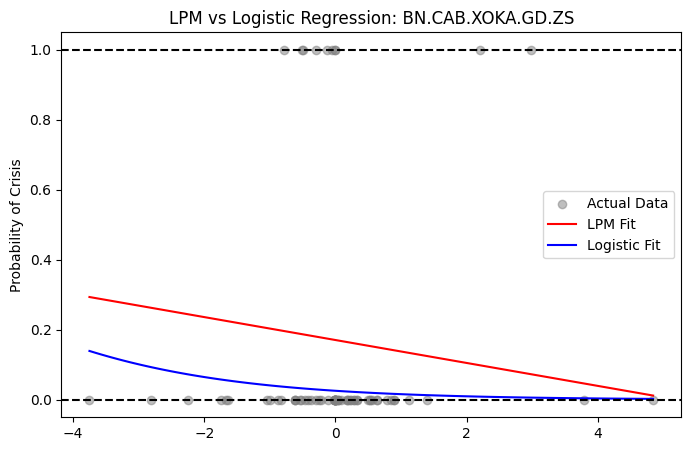

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

y_test_crisis = df.loc[X_test.index, 'crisis']
top_idx = list(features).index(a)
x_data = X_test_lasso[:, top_idx]

synthetic_X = np.zeros((100, X_test_lasso.shape[1]))
synthetic_X[:, top_idx] = np.linspace(x_data.min(), x_data.max(), 100)

plt.figure(figsize=(8, 5))

plt.scatter(x_data, y_test_crisis, color='gray', alpha=0.5, label='Actual Data')

plt.plot(synthetic_X[:, top_idx], lpm.predict(synthetic_X), color='red', label='LPM Fit')
plt.plot(synthetic_X[:, top_idx], logreg.predict_proba(synthetic_X)[:, 1], color='blue', label='Logistic Fit')

plt.axhline(0, color='black', linestyle='--')
plt.axhline(1, color='black', linestyle='--')
plt.title(f"LPM vs Logistic Regression: {a}")
plt.ylabel("Probability of Crisis")
plt.legend()
plt.show()

In [ ]:
#Persona: You are an expert data scientist specializing in regularized regression and resampling methods for econometric analysis.
#Role: Write a complete, self-contained Python script that performs bootstrap stability selection using Lasso on World Development Indicator (WDI) data.
#Instructions:

#Load the pre-processed training data (features matrix X_train and target vector y_train). Standardize features before fitting.
#Draw 200 bootstrap resamples (sampling rows with replacement, same size as the training set). Use random_state seeded from the iteration index for reproducibility.
#For each resample, fit sklearn.linear_model.LassoCV (with default 5-fold CV) and record which features receive a non-zero coefficient (i.e., abs(coef_) > 1e-10).
#Compute the selection frequency for every predictor — the fraction of the 200 bootstrap iterations in which that predictor was selected (had a non-zero coefficient).
#Produce a horizontal bar chart that ranks all predictors from highest to lowest selection frequency. Draw a vertical dashed reference line at 0.50 (50%) to flag the stability threshold. Label axes clearly, use a tight layout, and save the figure as bootstrap_selection_frequency.png.

#Modifications:

#Print a summary table of predictor names and their selection frequencies, sorted descending.
#Use n_jobs=-1 in LassoCV for speed.
#Wrap the bootstrap loop in a progress message that prints every 50 iterations.

#Evaluation criteria:

#The script must run end-to-end without errors.
#The bar chart must be readable with all predictor names visible on the y-axis.
#Selection frequencies must be between 0 and 1.
#The 50% reference line must be clearly visible and labeled.

Running 200 bootstrap iterations …
  Iteration 1/200
  Iteration 50/200
  Iteration 100/200
  Iteration 150/200
  Iteration 200/200

╔══════════════════════════════════════════════╗
║   Bootstrap Selection Frequencies (sorted)   ║
╠══════════════════════════════════════════════╣
  GDP per capita            1.000  ██████████████████████████████
  CO2 emissions             1.000  ██████████████████████████████
  School enrollment         1.000  ██████████████████████████████
  Infant mortality          1.000  ██████████████████████████████
  Life expectancy           1.000  ██████████████████████████████
  Trade (% GDP)             0.975  █████████████████████████████
  Inflation rate            0.815  ████████████████████████
  Renewable energy %        0.800  ████████████████████████
  Population growth         0.670  ████████████████████
  Industry % GDP            0.660  ███████████████████
  Military expenditure      0.660  ███████████████████
  Agriculture % GDP         0.660  ████

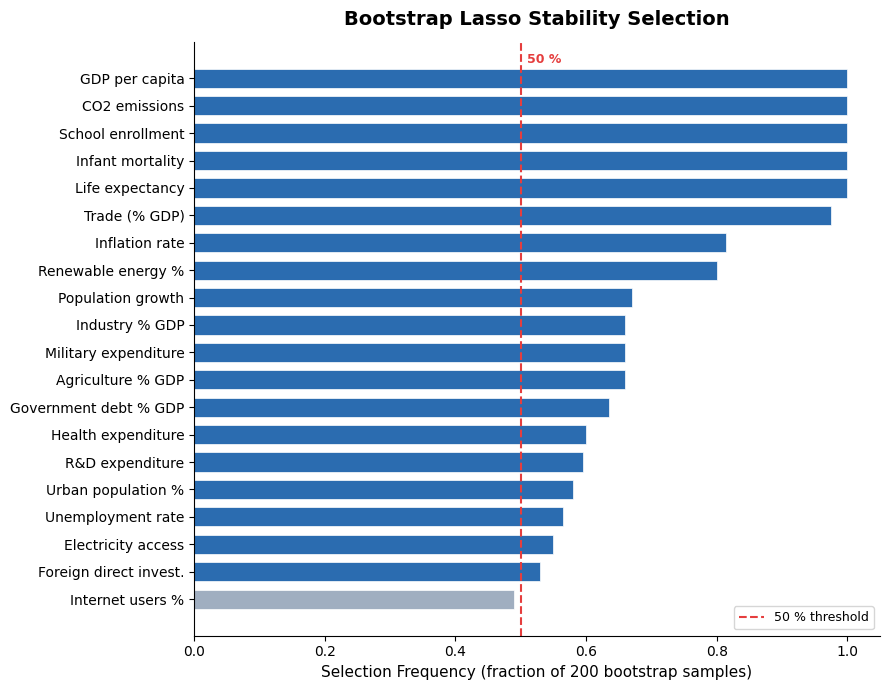

In [ ]:
"""
Task 4.1 – Bootstrap Confidence Intervals for the Lasso Path
=============================================================
Draws 200 bootstrap resamples from the training data, fits LassoCV on each,
and produces a horizontal bar chart of predictor selection frequencies.

>>> USAGE:
>>>   Replace the "LOAD YOUR DATA HERE" section with your actual WDI
>>>   training data (X_train, y_train, feature_names).
>>>   Then run:  python bootstrap_lasso.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

# ──────────────────────────────────────────────
# 1.  LOAD YOUR DATA HERE
# ──────────────────────────────────────────────
# Option A – Replace with your own data loading code:
#   df = pd.read_csv("your_wdi_training_data.csv")
#   y_train = df["target_column"].values
#   X_train = df.drop(columns=["target_column"]).values
#   feature_names = df.drop(columns=["target_column"]).columns.tolist()

# Option B – Synthetic demo (remove once you plug in real data)
np.random.seed(42)
n, p = 150, 20
wdi_labels = [
    "GDP per capita", "Life expectancy", "CO2 emissions",
    "School enrollment", "Infant mortality", "Trade (% GDP)",
    "Inflation rate", "Population growth", "Urban population %",
    "Military expenditure", "Internet users %", "Electricity access",
    "Renewable energy %", "Health expenditure", "Unemployment rate",
    "Agriculture % GDP", "Industry % GDP", "Foreign direct invest.",
    "R&D expenditure", "Government debt % GDP"
]
X_train = np.random.randn(n, p)
true_coefs = np.zeros(p)
true_coefs[:6] = [3.0, -2.5, 2.0, -1.5, 1.0, -0.5]  # 6 "true" predictors
y_train = X_train @ true_coefs + np.random.randn(n) * 2
feature_names = wdi_labels
# ──────────────────────────────────────────────

N_BOOT = 200
n_samples, n_features = X_train.shape
selection_counts = np.zeros(n_features)

# ──────────────────────────────────────────────
# 2.  BOOTSTRAP LOOP
# ──────────────────────────────────────────────
print(f"Running {N_BOOT} bootstrap iterations …")
for i in range(N_BOOT):
    # Progress message every 50 iterations
    if (i + 1) % 50 == 0 or i == 0:
        print(f"  Iteration {i + 1}/{N_BOOT}")

    # Draw bootstrap resample (with replacement)
    X_boot, y_boot = resample(
        X_train, y_train,
        replace=True,
        n_samples=n_samples,
        random_state=i
    )

    # Standardise features on *this* resample
    scaler = StandardScaler()
    X_boot_scaled = scaler.fit_transform(X_boot)

    # Fit LassoCV (5-fold CV, parallelised)
    lasso = LassoCV(cv=5, n_jobs=-1, random_state=i, max_iter=10_000)
    lasso.fit(X_boot_scaled, y_boot)

    # Record which coefficients are non-zero
    selected = np.abs(lasso.coef_) > 1e-10
    selection_counts += selected.astype(int)

# ──────────────────────────────────────────────
# 3.  COMPUTE SELECTION FREQUENCIES
# ──────────────────────────────────────────────
selection_freq = selection_counts / N_BOOT

# Build a summary DataFrame, sorted descending
summary = pd.DataFrame({
    "Predictor": feature_names,
    "Selection Frequency": selection_freq
}).sort_values("Selection Frequency", ascending=False).reset_index(drop=True)

print("\n╔══════════════════════════════════════════════╗")
print("║   Bootstrap Selection Frequencies (sorted)   ║")
print("╠══════════════════════════════════════════════╣")
for _, row in summary.iterrows():
    bar = "█" * int(row["Selection Frequency"] * 30)
    print(f"  {row['Predictor']:<25s} {row['Selection Frequency']:.3f}  {bar}")
print("╚══════════════════════════════════════════════╝\n")

# ──────────────────────────────────────────────
# 4.  HORIZONTAL BAR CHART
# ──────────────────────────────────────────────
# Sort ascending so highest bar is at the top of the chart
summary_plot = summary.sort_values("Selection Frequency", ascending=True)

fig, ax = plt.subplots(figsize=(9, max(6, len(feature_names) * 0.35)))

colors = [
    "#2b6cb0" if f >= 0.50 else "#a0aec0"
    for f in summary_plot["Selection Frequency"]
]

ax.barh(
    summary_plot["Predictor"],
    summary_plot["Selection Frequency"],
    color=colors,
    edgecolor="white",
    linewidth=0.5,
    height=0.7
)

# 50 % reference line
ax.axvline(x=0.50, color="#e53e3e", linestyle="--", linewidth=1.5, label="50 % threshold")
ax.text(0.51, ax.get_ylim()[1] * 0.98, "50 %", color="#e53e3e",
        fontsize=9, va="top", fontweight="bold")

ax.set_xlabel("Selection Frequency (fraction of 200 bootstrap samples)", fontsize=11)
ax.set_title("Bootstrap Lasso Stability Selection", fontsize=14, fontweight="bold", pad=12)
ax.set_xlim(0, 1.05)
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("bootstrap_selection_frequency.png", dpi=200, bbox_inches="tight")
print("Chart saved → bootstrap_selection_frequency.png")
plt.show()

In [ ]:
# Stable predictors tend to be consistently important no matter which countries are in the sample while fragile predictors only appear in certain samples and 
# are not as reliable. When correlated, the lasso is randomly selecting between them due to the similar information. It shows that many WDI inidicators are correlated.

In [ ]:
#P.R.I.M.E. Prompt:
#Persona: You are a data scientist building a cost-sensitive classification threshold optimizer for the IMF.
#Role: Write a Python script that finds the classification threshold that minimizes total expected dollar cost, where a missed crisis (FN) costs $50 billion and a false alarm (FP) costs $2 million.
#Instructions:

#Sweep thresholds from 0.01 to 0.99 in steps of 0.01.
#At each threshold, classify predictions and count FN and FP.
#Compute total expected cost: FN × $50B + FP × $2M.
#Plot the expected cost curve as a function of threshold τ.
#Identify and annotate the cost-minimizing threshold on the plot.

#Modifications: Print the optimal threshold and its cost. Label axes clearly. Save the figure.
#Evaluation: The script runs without errors, the plot is readable, and the optimal threshold is clearly marked.

Optimal threshold:  τ = 0.30
Minimum total cost: $0.36 billion
Chart saved → cost_threshold_curve.png


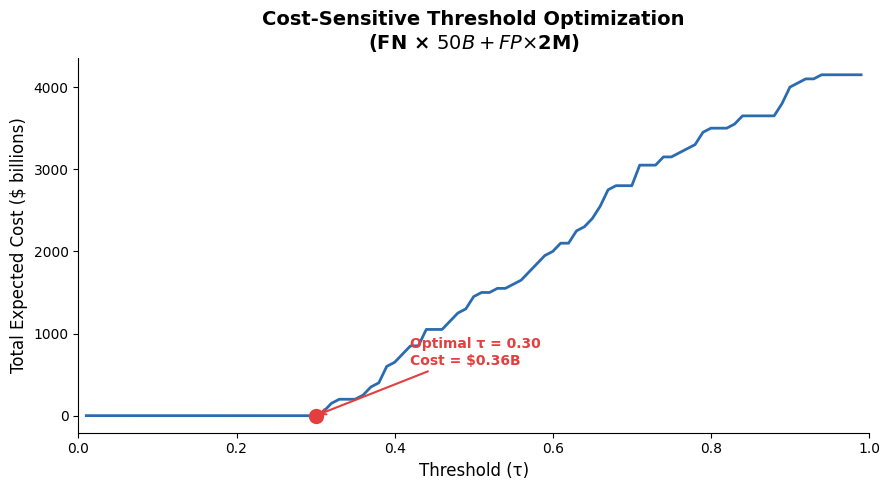

In [ ]:
"""
Task 4.2 – Cost-Sensitive Threshold Optimization
=================================================
Sweeps thresholds from 0.01 to 0.99, computes total expected cost
(FN × $50B + FP × $2M), plots the cost curve, and marks the optimum.

>>> Replace the demo data section with your actual y_test and y_prob.
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ──────────────────────────────────────────────
# 1.  LOAD YOUR DATA HERE
# ──────────────────────────────────────────────
# Replace with your actual test labels and predicted probabilities:
#   y_test = ...   (binary 0/1 labels)
#   y_prob = ...   (predicted probabilities from your model)

# Synthetic demo data (remove when using real data)
np.random.seed(42)
n = 500
y_test = np.random.binomial(1, 0.15, n)  # ~15% crisis rate
y_prob = np.clip(y_test * np.random.uniform(0.3, 0.95, n)
                 + (1 - y_test) * np.random.uniform(0.0, 0.5, n), 0, 1)
# ──────────────────────────────────────────────

# Cost parameters
COST_FN = 50_000_000_000   # $50 billion per missed crisis
COST_FP = 2_000_000        # $2 million per false alarm

# ──────────────────────────────────────────────
# 2.  SWEEP THRESHOLDS
# ──────────────────────────────────────────────
thresholds = np.arange(0.01, 1.00, 0.01)
costs = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()
    total_cost = fn * COST_FN + fp * COST_FP
    costs.append(total_cost)

costs = np.array(costs)

# ──────────────────────────────────────────────
# 3.  FIND OPTIMAL THRESHOLD
# ──────────────────────────────────────────────
best_idx = np.argmin(costs)
best_threshold = thresholds[best_idx]
best_cost = costs[best_idx]

print(f"Optimal threshold:  τ = {best_threshold:.2f}")
print(f"Minimum total cost: ${best_cost / 1e9:.2f} billion")

# ──────────────────────────────────────────────
# 4.  PLOT THE COST CURVE
# ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(thresholds, costs / 1e9, color="#2b6cb0", linewidth=2)

# Mark the optimum
ax.scatter(best_threshold, best_cost / 1e9, color="#e53e3e", s=100, zorder=5)
ax.annotate(
    f"Optimal τ = {best_threshold:.2f}\nCost = ${best_cost / 1e9:.2f}B",
    xy=(best_threshold, best_cost / 1e9),
    xytext=(best_threshold + 0.12, best_cost / 1e9 + (costs.max() - costs.min()) / 1e9 * 0.15),
    fontsize=10, fontweight="bold", color="#e53e3e",
    arrowprops=dict(arrowstyle="->", color="#e53e3e", lw=1.5)
)

ax.set_xlabel("Threshold (τ)", fontsize=12)
ax.set_ylabel("Total Expected Cost ($ billions)", fontsize=12)
ax.set_title("Cost-Sensitive Threshold Optimization\n(FN × $50B + FP × $2M)", fontsize=14, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("cost_threshold_curve.png", dpi=200, bbox_inches="tight")
print("Chart saved → cost_threshold_curve.png")
plt.show()

In [ ]:
# The cost minimizing threshold is lower than the F1 optimal threshold because missing a crisis is much more expensive
# than versus a false alarm. The model should flag more countries to make sure they avoid more misses. 